In [1]:
import numpy as np
import sklearn
from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

import scipy.stats
from scipy.stats import norm
from scipy.stats import uniform
from scipy import optimize
from astroML import stats as astroMLstats
from astroML.datasets import fetch_hogg2010test
from sklearn import mixture

In [2]:
#importo i dati
data = np.load('formationchannels.npy')

#li converto in un array monodimensionale con np.newaxis
data[np.newaxis]


#definisco il numero di componenti (DOVREI CICLARE SU QUESTO NUMERO)
N_comp = 10

#inizializzo un vettore per il test AIC
AIC = np.zeros(N_comp)

In [3]:
#alleno il mio modello sui miei dati
for i in range (N_comp):
    clf = mixture.GaussianMixture(n_components=i+1)
    clf.fit(data)
    AIC[i] = clf.aic(data)


#print(clf.means_ , clf.covariances_)
AIC

array([20945.97260859, 20754.07724228, 20083.30915531, 20101.69537048,
       20114.34021301, 20120.73977595, 20128.50731808, 20130.63982093,
       20133.33477927, 20138.29347965])

AIC TEST:

3

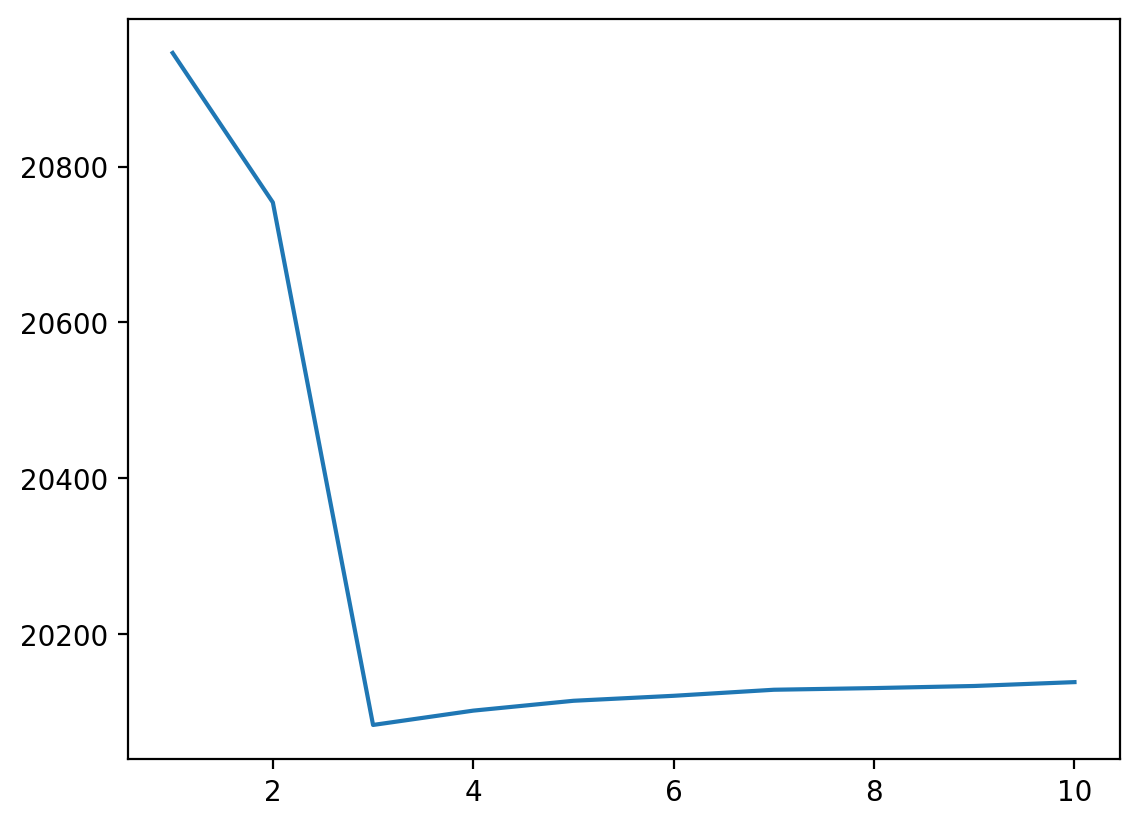

In [4]:
N = np.linspace(1,N_comp , N_comp)

#plot AIC in function of N
plt.plot(N,AIC)
min_index = np.where(AIC == min(AIC))

#the minimum is the best!
index = int(N[min_index[0][0]])
index

Creo plot con miglior numero di componenti gaussiane

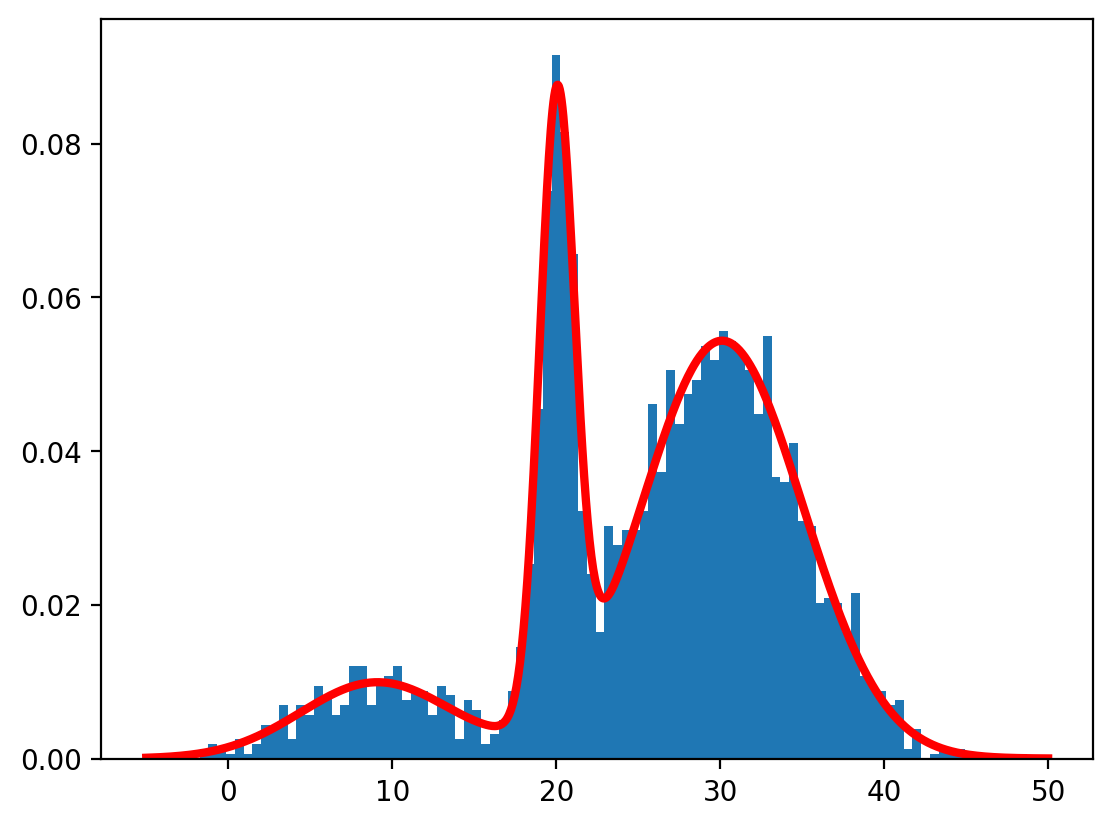

In [7]:
#rappresento i miei dati in un istogramma
plt.hist(data, bins = 100, density = True)

#creo i grafici delle ditribuzioni gaussiane con cui voglio plottare il mio grafico
x = np.linspace(-5,50, 1000)
gauss = np.zeros((index , 1000))
Norm_tot= np.zeros(1000)

clf = mixture.GaussianMixture(n_components=index)
clf.fit(data)

#plotto tutte le distribuzioni ciclando sul numero di componenti gaussiane
for i in range (index):
    
    #sommo ogni gaussiana con il proprio peso
    Norm_tot += clf.weights_[i]*norm.pdf(x , clf.means_[i][0], np.sqrt(clf.covariances_[i][0]))

#plotto la somma delle gaussiane
plt.plot(x, Norm_tot, linewidth=3, color = 'r')
plt.show()

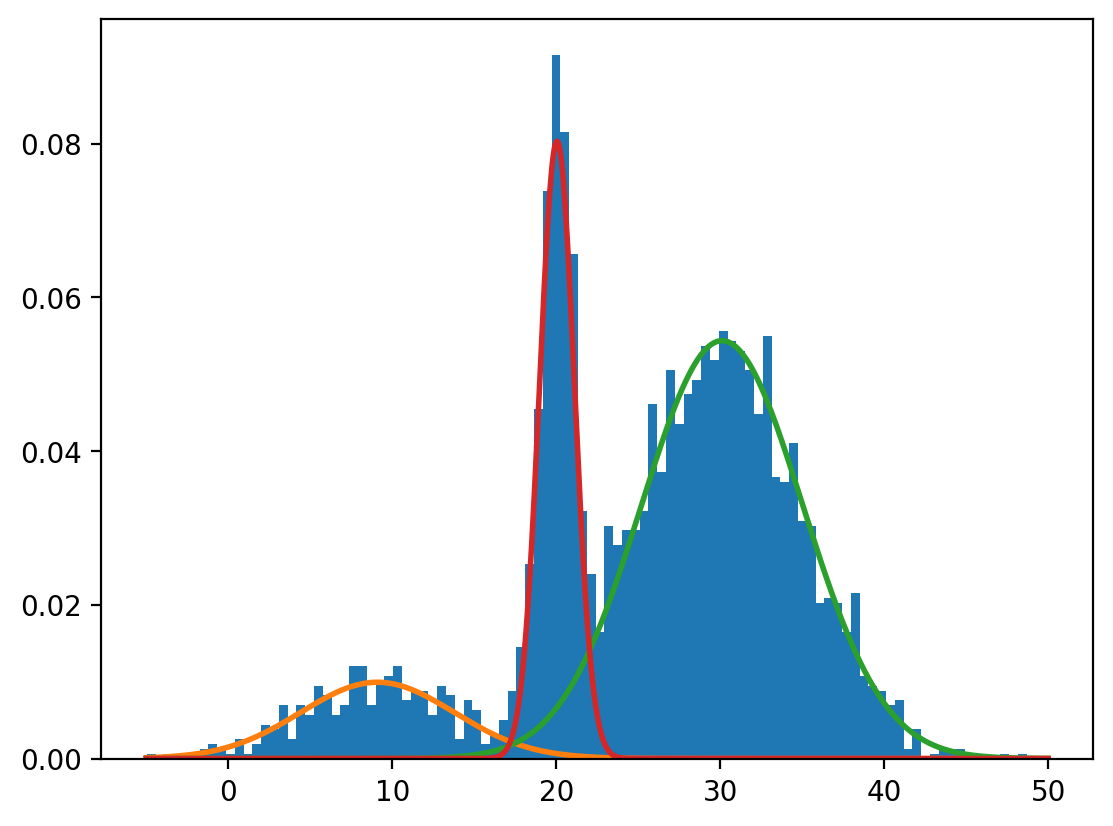

In [8]:
plt.hist(data, bins = 100, density = True)

for i in range(index):
    #riempio un array con ogni gaussiana
    gauss[i , :] =  clf.weights_[i]*norm.pdf(x , clf.means_[i][0], np.sqrt(clf.covariances_[i][0]))
    plt.plot(x, gauss[i, :], linewidth=2)

plt.show()